# ORTools: Optimization

## 1. Mathematical foundations

### 1.1. Principles of convexity

#### Convex set
A set $\mathcal{S}$ is convex if the line between any two points $s_1,s_2\in\mathcal{S}$ lies completely inside $\mathcal{S}$. Formally:

$$\lambda s_1+(1-\lambda)s_2\in \mathcal{S}\qquad\forall\;\lambda\in[0,1]$$

:::{image} ../image/chap_02/convex_set.svg
:height: 250px
:align: center
:::

#### Convex function
A function $f(x)$ is convex if (1) its domain is convex and (2) the curve between any two points $x_1,x_2\in\text{dom}(f)$ lies under the segment between them:

$$f(\lambda x_1+(1-\lambda)x_2)\leq\lambda f(x_1)+(1-\lambda)f(x_2)\qquad\forall\;\lambda\in[0,1]$$

Equivalently, $f(x)$ is also convex if it satisfies one of these (differentiability assumed):
- First-order condition: The tangent line at any point lies below the graph of the function: 

$$f(x_2)\geq f(x_1)+\nabla f(x_1)^\top(x_2-x_1)$$

- Second-order condition: The function is curved upward in all directions (think of a bowl):

$$\nabla^2f(x)\succeq0$$

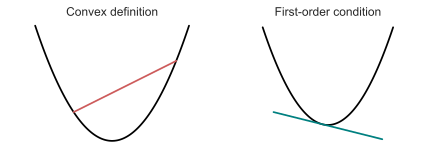

In [1]:
import sys; sys.path.append('..')
from mlkit import np, plt, sns

def f(x):
    return x ** 2 / 2

x_graph = np.linspace(-3, 3, 100)
y_graph = f(x_graph)

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(6,2))
ax[0].plot(x_graph, y_graph, 'k')
ax[0].axis('equal')
ax[0].grid(False)
ax[0].set_axis_off()
ax[0].set_title('Convex definition')

x_dom = np.array([-1.5, 2.5])
y_dom = f(x_dom)
ax[0].plot(x_dom, y_dom, 'indianred')

ax[1].plot(x_graph, y_graph, 'k')
ax[1].axis('equal')
ax[1].grid(False)
ax[1].set_axis_off()
ax[1].set_title('First-order condition')

def tangent_line(x):
    return -0.25*x - 0.03125

x_tng = np.array([-2.5, 2.5])
y_tng = tangent_line(x_tng)
ax[1].plot(x_tng, y_tng, 'teal')

plt.show()

:::{note}
- Any local minimum of a convex function $f$ is also its global minimum.
- If $f$ is convex then $-f$ is concave, whose domain is still a convex set.
- There is no such thing as "a concave set".
:::

### 1.2. Derivative tests
[Derivative tests] use $f'(x)$ and $f''(x)$ to read a function's shape. The first derivative controls [monotonicity] and flags [stationary points]; the second derivative controls [curvature] and helps locate [inflection points].

[Derivative tests]: https://en.wikipedia.org/wiki/Derivative_test
[monotonicity]: https://en.wikipedia.org/wiki/Monotonic_function
[stationary points]: https://en.wikipedia.org/wiki/Stationary_point
[curvature]: https://en.wikipedia.org/wiki/Concave_function
[inflection points]: https://en.wikipedia.org/wiki/Inflection_point

In [3]:
import sys; sys.path.append('..')
from mlkit import np, sym, plt

In [5]:
bound_left, bound_right = -2.2, 2.6

map_sign_color = {
    'negative': 'indianred',
    'positive': 'royalblue',
    '-': 'indianred',
    '+': 'royalblue',
}

def phi(x):
    return (2*x**5 - x**4 - 10*x**3) / 16

x = sym.Symbol('x')
y = phi(x)

derivative_1st = sym.lambdify(x, y.diff(), 'numpy')

y

x**5/8 - x**4/16 - 5*x**3/8

#### First derivative
The first derivative represents the function's *instantaneous velocity*. So if we know the sign of $f'(x)$ on each interval, we immediately know where $f(x)$ is increasing or decreasing. Here are quick rules for geometric meaning:
- $f'(x)>0$: graph rises as $x$ increases (increasing).
- $f'(x)<0$: graph falls as $x$ increases (decreasing).
- Larger $|f'(x)|$ means steeper graph (changes faster). Smaller $|f'(x)|$ means flatter graph (changes more slowly).
- $f'(x)=0$: a stationary point (flat tangent). It *may* be a local [extremum] but it needs further checks (sign change or second derivative test) to classify it.
- In higher dimensions, a zero gradient $\nabla f(\mathbf{x}) = \mathbf{0}$ indicates a flat tangent plane. While this can be a peak or valley, it often represents a [saddle point], where the function increases in one direction but decreases in another.

[extremum]: https://en.wikipedia.org/wiki/Maximum_and_minimum
[saddle point]: https://en.wikipedia.org/wiki/Saddle_point

::::{admonition} Case
:class: tip

Let's take a look at the function:

$$y=\phi(x)=\frac{2x^5-x^4-10x^3}{16}$$

First, we build the sign table for $\phi'(x)$ and what it implies for $\phi(x)$:

|$x$    |$-\infty$|   |$-1.544$|   |$0$|   |$1.944$|   |$\infty$|
|:-----:|:-------:|:-:|:------:|:-:|:-:|:-:|:-----:|:-:|:------:|
|$f'(x)$|         |$+$|$0$     |$-$|$0$|$-$|$0$    |$+$|        |

<br>

Next, we plot $\phi(x)$ where red intervals indicate $\phi'(x)<0$ and blue intervals indicate $\phi'(x)>0$.

:::{image} ../export/chap_02/function_monotonicity.svg
:height: 300px
:align: center
:::
<br>

The black dots mark where $\phi'(x)=0$; these are stationary points. But not all of them behave the same:
- At $x \approx -1.544$, $\phi'(x)$ changes from positive to negative, so the function switches from increasing to decreasing. We conclude this is a local maximum.
- At $x \approx 1.944$, $\phi'(x)$ changes from negative to positive, so the function switches from decreasing to increasing. We conclude this is a local minimum.
- At $x=0$, the sign of $\phi'(x)$ stays negative on both sides, so the function keeps decreasing through the point. This is not a max or a min.

::::

In [6]:
list_stationary = [float(i) for i in sorted(sym.solveset(y.diff(), x))]
list_interval = [
    np.linspace(bound_left, list_stationary[0], 1000),
    np.linspace(list_stationary[0], list_stationary[1], 1000),
    np.linspace(list_stationary[1], list_stationary[2], 1000),
    np.linspace(list_stationary[2], bound_right, 1000),
]

fig, ax = plt.subplots()
ax.axhline(0, c='grey')

ax.plot(list_interval[0], phi(list_interval[0]), color=map_sign_color['+'], label='Increasing (velocity > 0)')
ax.plot(list_interval[1], phi(list_interval[1]), color=map_sign_color['-'], label='Decreasing (velocity < 0)')
ax.plot(list_interval[2], phi(list_interval[2]), color=map_sign_color['-'])
ax.plot(list_interval[3], phi(list_interval[3]), color=map_sign_color['+'])

for stationary in list_stationary:
    ax.plot(stationary, phi(stationary), 'ok')
    ax.axvline(stationary, ls='--', c='grey', alpha=0.5)

ax.legend()
ax.axis('scaled')
ax.grid(False)
ax.set_xticks(list_stationary)
ax.set_yticks([])

fig.savefig('../export/chap_02/function_monotonicity.svg', dpi=500, bbox_inches='tight')
plt.close(fig)

#### Second derivative
The [second derivative] represents the function's *instantaneous acceleration*.
- $f''(x)>0$: increasing velocity, the graph bends upward (convex).
- $f''(x)<0$: decreasing velocity, the graph bends downward (concave).
- Large $|f''(x)|$ means the graph has a sharp, tight turn. Small $|f''(x)|$ means the graph has a gentle, gradual curve.
- In higher dimensions, positive definite Hessian matrix $\nabla^2f(\mathbf{x})$ indicates a convex function.

[second derivative]: https://en.wikipedia.org/wiki/Second_derivative

::::{admonition} Case
:class: tip

Let's do the second-derivative test for $\phi(x)$. Here is how the table of sign of $\phi''(x)$ looks like:

|$x$     |$-\infty$|   |$-1.084$|   |$0$|   |$1.384$|   |$\infty$|
|:------:|:-------:|:-:|:------:|:-:|:-:|:-:|:-----:|:-:|:------:|
|$f''(x)$|         |$-$|$0$     |$+$|$0$|$-$|$0$    |$+$|        |

<br>

Next, we plot both $\phi(x)$ and $\phi'(x)$. Black dots are where $\phi''(x)=0$; they split the function into convex (blue) and concave (red) intervals clearly.

:::{image} ../export/chap_02/function_curvature.svg
:height: 300px
:align: center
:::

::::

In [18]:
list_inflection = [float(i) for i in sorted(sym.solveset(y.diff().diff(), x))]

list_interval = [
    np.linspace(bound_left, list_inflection[0], 1000),
    np.linspace(list_inflection[0], list_inflection[1], 1000),
    np.linspace(list_inflection[1], list_inflection[2], 1000),
    np.linspace(list_inflection[2], bound_right, 1000),
]

x_plot = np.linspace(bound_left+0.5, bound_right-0.5, 1000)

fig, ax = plt.subplots()
ax.axhline(0, c='grey')

ax.plot(x_plot, derivative_1st(x_plot), c='grey', label='Velocity')

ax.plot(list_interval[0], phi(list_interval[0]), color=map_sign_color['-'], label='Concave (acceleration < 0)')
ax.plot(list_interval[1], phi(list_interval[1]), color=map_sign_color['+'], label='Convex (acceleration > 0)')
ax.plot(list_interval[2], phi(list_interval[2]), color=map_sign_color['-'])
ax.plot(list_interval[3], phi(list_interval[3]), color=map_sign_color['+'])

for inflection in list_inflection:
    ax.plot(inflection, phi(inflection), 'ok')
    ax.plot(inflection, derivative_1st(inflection), 'ok')
    ax.axvline(inflection, ls='--', c='grey', alpha=0.5)

ax.legend()
ax.axis('scaled')
ax.grid(False)
ax.set_xticks(list_inflection)
ax.set_yticks([])

ax.text(
    x_plot[-1] - 0.1, derivative_1st(x_plot[-1]) - 0.1, 'Derivative', 
    fontsize=12, va='center', ha='right'
)

ax.text(
    list_interval[-1][-1] - 0.1, phi(list_interval[-1][-1]) + 0.1, 'Function', 
    fontsize=12, va='bottom', ha='center'
)

fig.savefig('../export/chap_02/function_curvature.svg', dpi=500, bbox_inches='tight')
plt.close(fig)

:::{note}
Combining both first and second derivative tests gives local extrema:
- If $f'(a)=0$ and $f''(a)>0$ then $x=a$ is a local minimum of $f(x)$
- If $f'(a)=0$ and $f''(a)<0$ then $x=a$ is a local maximum of $f(x)$
:::

### 1.3. Matrix definiteness
[Matrix definiteness] is the matrix version of "a scalar being positive or negative". It shows up everywhere in optimization because Hessians are (usually) symmetric, and their definiteness tells you about curvature (convex/concave).

[Matrix definiteness]: https://en.wikipedia.org/wiki/Definite_matrix

#### Definition and intuition
Positive definite is a direct generalization of "positive":
- A scalar is positive ($a>0$) if multiplying by $a$ preserves the sign of any number $x\neq0$: Formally: $x(ax)>0$.
- A matrix is positive definite ($\mathbf{A}\succ0$) if the transformation $\mathbf{A}$ never flips any vector $\mathbf{x}\neq\mathbf{0}$ into a negative direction. Formally: $\mathbf{x}^\top (\mathbf{Ax}) > 0$.

:::{note}
In practice, definiteness is usually discussed for square, symmetric matrices, which is exactly the case for Hessians in most optimization problems.
:::

#### Types and notation
Let $\mathbf{A} \in \mathbb{R}^{N\times N}$ be symmetric.

|Type of definiteness|Notation|Scalar version|Definition|
|:-|:-:|:-:|:-|
|Positive definite| $\mathbf{A}\succ0$ | $a>0$ | $\mathbf{x}^\top\mathbf{Ax}>0\;\forall\;\mathbf{x}\neq\mathbf{0}$ |
|Negative definite| $\mathbf{A}\prec0$ | $a<0$ | $\mathbf{x}^\top\mathbf{Ax}<0\;\forall\;\mathbf{x}\neq\mathbf{0}$ |
|Positive semi-definite| $\mathbf{A}\succeq0$ | $a\geq0$| $\mathbf{x}^\top\mathbf{Ax}\geq0\;\forall\;\mathbf{x}$ |
|Negative semi-definite| $\mathbf{A}\preceq0$ | $a\leq0$| $\mathbf{x}^\top\mathbf{Ax}\leq0\;\forall\;\mathbf{x}$ |
|Non-definite||| $\exists\;\mathbf{x}:\mathbf{x}^\top\mathbf{Ax}>0;\;\exists\;\mathbf{y}:\mathbf{y}^\top\mathbf{Ay}>0$ |
|Shifted positive definite| $\mathbf{A}\succ\mu$ | $a>\mu$ | $\mathbf{A}-\mu\mathbf{I}\succ0$

### Definiteness tests
You can check definiteness in a few standard ways (again, assume $\mathbf{A} \in \mathbb{R}^{N\times N}$ is symmetric).
- Quadratic test (definition): look at $\mathbf{x}^\top\mathbf{Ax}$ and use the definitions. This is the most direct test, but not always the easiest to compute.
- Spectral test: check eigenvalues $\lambda_n$.
    - If all are positive or negative then $\mathbf{A}$ is definite
    - If all are $\geq0$ or $\leq0$ then $\mathbf{A}$ is semi-definite
    - If some are positive and some are negative then $\mathbf{A}$ is non-definite
- Sylvester test: check determinants of all leading principal minors $\det(\mathbf{A}_{1:n,1:n})$.
    - If all are positive then $\mathbf{A}$ is positive definite
    - If they have alternating signs, starting from positive, then $\mathbf{A}$ is nagative definite.

## 2. Unconstrained optimization
In unconstrained optimization, we want to find an $\mathbf{x}\in\mathbb{R}^N$ that minimizes a scalar objective $f:\mathbb{R}^N\mapsto\mathbb{R}$:

$$\mathbf{x}^\star=\arg\min f(\mathbf{x})$$

In practice, most algorithms are *local* methods: they aim for a point where $\nabla f(\mathbf{x}^\star)=\mathbf{0}$, which is a neccessary condition for a local minimum.

### 2.1. Theoretical frameworks
To optimize a function iteratively, we move from a starting point $\mathbf{x}_0$ through a series of steps to reach a local minimum. The two most prominent strategies for deciding how to take these steps are [line search] (direction first, then step size) and [trust region] (region first, then step) methods. In practice, line search is the standard workhorse for most Data Science and Deep Learning applications. This approach find the search direction $\mathbf{p}_k$ and step size $\alpha_k$ at iteration $k$:

$$\mathbf{x}_{k+1}=\mathbf{x}_k+\alpha_k\mathbf{p}_k$$

$\mathbf{p}_k$ is usually chosen as a descent direction, meaning $\mathbf{p}_k^\top\nabla f(\mathbf{x}_k)<0$. To find $\mathbf{p}_k$, we minimize a local surrogate $\sigma_k(\mathbf{x})$ (reconstructed at each step) that approximates $f(\mathbf{x})$ near the current position $\mathbf{x}_k$. $\sigma$ is taken to be the Taylor expansion of the objective, usually truncated at first order ([Gradient Descent]) or at second order ([Newton-Raphson]).

[line search]: https://en.wikipedia.org/wiki/Line_search
[trust region]: https://en.wikipedia.org/wiki/Trust_region
[Gradient Descent]: https://en.wikipedia.org/wiki/Gradient_descent
[Newton-Raphson]: https://en.wikipedia.org/wiki/Newton%27s_method_in_optimization

:::{note}

In the next section, we only go through the core mathematical idea of Gradient Descent and Newton-Raphson. In practice, we often use more advanced variants (SGD, Adam, BFGS, L-BFGS, etc.) that build upon these two basic algorithms.

:::

### 2.2. Newton-Raphson
This method uses the second Taylor expansion as the surrogate:

$$
\sigma_k(\mathbf{x})
= f(\mathbf{x}_k)
+ \mathbf{g}_k^\top(\mathbf{x}
- \mathbf{x}_k)
+ \dfrac{1}{2}(\mathbf{x} - \mathbf{x}_k)^\top \mathbf{H}_k(\mathbf{x}-\mathbf{x}_k)
$$

Here, $\mathbf{g}_k=\nabla f(\mathbf{x}_k)$ and $\mathbf{H}_k=\nabla^2 f(\mathbf{x}_k)$ are the gradient and Hessian evaluated at $\mathbf{x}_k$. Solving for $\mathbf{x}_{k+1}=\arg\min \sigma_k(\mathbf{x})$, we have the update step:

$$\mathbf{p}_k=-\mathbf{H}_k^{-1}\mathbf{g}_k$$

The intuition is that the Hessian $\mathbf{H}_k$ captures the local curvature of $f(\mathbf{x}_k)$, allowing us to adjust the step direction and size accordingly. This often leads to faster convergence compared to first-order methods, especially near the optimum where the quadratic approximation is more accurate.

:::{admonition} Case
:class: tip

We derive the next Newton-Raphson position: $\mathbf{x}_{k+1}=\arg\min\sigma_k(\mathbf{x})$ as follows:

*Step 1*: Find the derivative of $\mathbf{z}=(\mathbf{x} - \mathbf{x}_k)^\top \mathbf{H}_k(\mathbf{x}-\mathbf{x}_k)$. Let $\mathbf{y}=\mathbf{x}-\mathbf{x}_k$ then $\mathbf{z}=\mathbf{y}^\top\mathbf{H}_k\mathbf{y}$. Apply chain rule:

$$\begin{aligned}
\nabla_\mathbf{x}\mathbf{z}
&= \nabla_\mathbf{y}\mathbf{z}\cdot\nabla_\mathbf{x}\mathbf{y} \\
&= 2\mathbf{H}_k\mathbf{y} \\
&= 2\mathbf{H}_k(\mathbf{x}-\mathbf{x}_k)
\end{aligned}$$

*Step 2*: Find the gradient and Hessian of $\sigma_k(\mathbf{x})$:

$$
\begin{aligned}
\nabla \sigma_k(\mathbf{x}) &= \mathbf{g}_k+\mathbf{H}_k(\mathbf{x}-\mathbf{x}_k) \\
\nabla^2 \sigma_k(\mathbf{x}) &= \mathbf{H}_k \succ 0
\end{aligned}
$$

*Step 3*: Solve for $\mathbf{x}_{k+1}$. As $\nabla^2\sigma_k(\mathbf{x})\succ 0$, $\sigma_k$ is convex and thus $\arg\min\sigma_k(\mathbf{x})$ is the root of $\nabla\sigma_k(\mathbf{x})=0$. Solving this gives us:

$$\mathbf{x}_{k+1}=\mathbf{x}_k-\mathbf{H}_k^{-1}\mathbf{g}_k$$

:::

:::{note}
Newton-Raphson is originally a [root finding] method, which solves for $f(\mathbf{x})=0$ and the update formula is:

$$\mathbf{x}_{k+1}=\mathbf{x}_k-\nabla f(\mathbf{x}_k)^{-1} f(\mathbf{x}_k)$$

If we solve for $\nabla f(\mathbf{x})=\mathbf{0}$, we get the same update formula in optimization.
:::

[root finding]: https://en.wikipedia.org/wiki/Newton%27s_method

### 2.3. Gradient Descent
This method replaces the expensive Hessian $\mathbf{H}_k$ with an $\eta$-parameterized quantity as follows:

$$
\sigma_k(\mathbf{x})
= f(\mathbf{x}_k)
+\mathbf{g}_k^\top(\mathbf{x}-\mathbf{x}_k)
+\frac{1}{2\eta}\|\mathbf{x}-\mathbf{x}_k\|_2^2
$$

This approximation is less accurate than Taylor series but is much simpler to compute. It also introduces a parameter $\eta$, which compensates for the loss of accuracy. Solving for next location $\mathbf{x}_{k+1}$ is the same for both Newton-Raphson and Gradient Descent, giving us the famous update formula:

$$\mathbf{x}_{k+1}=\mathbf{x}_k-\eta\nabla f(\mathbf{x}_k)$$

:::{note}

The main difference between Newton-Raphson and Gradient Descent is the choice of step size (what we multiply with $\mathbf{g}_k$). While Newton-Raphson uses an entire matrix (the Hessian), what Gradient Descent uses is only a scalar. This Gradient Descent's lack of multi-dimensional adaption makes it scale-dependent and needs normalization.

Imagine a function of $x_1,x_2$, where $x_1$ has a significantly larger range than $x_2$. Even with the capability of being configurable, there's no way we can choose a learning rate that can work well for both directions. This is why Gradient Descent requires standardization to actually work.

:::

:::{admonition} Intuition
:class: attention

Think about an optimization problem as a *hiking guide*, where the objective function ($f$) measures your *altitude* ($y$) given your *latitude and longitude* ($\mathbf{x}$). You are aiming for the lowest point (optimal) or to get as low as possible (sub-optimal).

The map is foggy, but from where you are you can always look around and tell which way is *downhill* (gradient $\mathbf{g}$). It's obvious to follow that direction, step by step (Gradient Descent).

With more time observing, you also know how steepness changes around you, the *curvature* (Hessian $\mathbf{H}$). You can use this information to pick smarter steps (Newton-Raphson). You will reach the bottom in fewer steps, even though each step takes longer.

:::

## 3. Constrained optimization
The general form of a constrained optimization problem:

$$
\begin{aligned}
    \min_\mathbf{x}\quad &f(\mathbf{x}) \\
    \text{subject to}\quad &\mathbf{g}(\mathbf{x})\leq\mathbf{0} \\
    & \mathbf{h}(\mathbf{x})=\mathbf{0}
\end{aligned}
$$

Where $\mathbf{g}$ is the set of inequality constraints and $\mathbf{h}$ is the set of equality constraints. Here are some important terms:
- If $g_i(\mathbf{x})=0$, then $g$ *actives* at $\mathbf{x}$
- If $\mathbf{x}$ satisfies all constraints then it is a *feasible solution*
- If $f(\mathbf{x})\leq f(\mathbf{x}^\star)+\epsilon$ then $\mathbf{x}$ is an *$\epsilon$-suboptimal solution*

:::{admonition} Case
:class: tip

Consider the constrained optimization problem:

$$\begin{aligned}
\min \quad & f(\mathbf{x}) = 3x_1 + 4x_2 \\
\text{s.t.} \quad & h(\mathbf{x}) = x_1^2 + x_2^2 - 25 \leq 0
\end{aligned}$$

As $h(\mathbf{x})=0$, we can do the following derivation:

$$
\begin{aligned}
f(\mathbf{x})
&= f(\mathbf{x})+\lambda h(\mathbf{x}) \\
&= 3x_1+4x_2+\lambda(x_1^2+x_2^2-25) \\
&= 
    \underbrace{ \lambda \left( x_1 + \frac{3}{2\lambda} \right)^2 }_{\geq 0} +
    \underbrace{ \lambda \left( x_2 + \frac{4}{2\lambda} \right)^2 }_{\geq 0} +
    \left(-25\lambda - \frac{25}{4\lambda}\right) \\
&\geq -\left(25\lambda + \frac{25}{4\lambda}\right) = \ell(\lambda)
\end{aligned}
$$

$\ell(\lambda)$ is a parameterized lower bound for the original objective $f(\mathbf{x})$. In order to minimize $f(\mathbf{x})$, we maximize $\ell(\lambda)$ because each $\lambda$ gives a valid but potentially weak lower bound, and the best use of a family of lower bounds is to take the tightest one; if you don't maximize it, you're just using a weaker bound than necessary.

According to AM-GM inequality, $\ell(\lambda)$ reaches its maximum at $\lambda^\star=0.5$, giving us the optimal solution: $(x_1,x_2)=(-3,-4)$.

:::

### 3.1. Lagrange multipliers
The introductory example above illustrates the core idea of [Lagrange multipliers]: we construct a new objective which combines the original objective and the constraints, allowing us to optimize without explicitly enforcing the constraints. Generally, the Lagrangian is defined as:

$$
\mathcal{L}(\mathbf{x},\boldsymbol{\lambda},\boldsymbol{\mu})
= f(\mathbf{x})
+ \boldsymbol{\lambda}^\top \mathbf{g}(\mathbf{x}) 
+ \boldsymbol{\mu}^\top \mathbf{h}(\mathbf{x})
$$

where $\lambda_i>0,\mu_j$ are the Lagrange multipliers associated with the inequality and equality constraints, respectively. The constrained primal problem can be transform into finding the saddle point of the Lagrangian. For fixed multipliers $(\boldsymbol{\lambda},\boldsymbol{\mu})$, minimizing over $\mathbf{x}$ gives the *Lagrange dual function*:

$$
\ell(\boldsymbol{\lambda},\boldsymbol{\mu})
:=\min_{\mathbf{x}}\ \mathcal{L}(\mathbf{x},\boldsymbol{\lambda},\boldsymbol{\mu})
$$

which provides a lower bound on the primal objective value. Maximizing this lower bound over feasible multipliers yields the *Lagrange dual problem*:

$$\max_{\boldsymbol{\lambda},\ \boldsymbol{\mu}}\ \ell(\boldsymbol{\lambda},\boldsymbol{\mu})$$

Moreover, $\ell(\boldsymbol{\lambda},\boldsymbol{\mu})$ is always concave in $(\boldsymbol{\lambda},\boldsymbol{\mu})$, so the dual is a convex optimization problem.


[Lagrange multipliers]: https://en.wikipedia.org/wiki/Lagrange_multiplier

#### Duality
[Duality] is about two perspectives of an optimization problem: the primal problem $\min f(\mathbf{x})$ and the dual problem $\max\ell(\boldsymbol{\lambda},\boldsymbol{\mu})$. This principle also says that for any feasible solution, [weak duality] always holds true:

$$\min f(\mathbf{x})\geq\max\ell(\boldsymbol{\lambda},\boldsymbol{\mu})$$

When the problem is a [convex optimization] problem, [strong duality] holds true. In other words, the [duality gap] is zero.

[Duality]: https://en.wikipedia.org/wiki/Duality_(optimization)
[weak duality]: https://en.wikipedia.org/wiki/Weak_duality
[strong duality]: https://en.wikipedia.org/wiki/Strong_duality
[convex optimization]: https://en.wikipedia.org/wiki/Convex_optimization
[duality gap]: https://en.wikipedia.org/wiki/Duality_gap

### 3.2. KKT conditions
This is a set of conditions that must be satisfied at the optimal solution of a constrained optimization problem. They generalize the method of Lagrange multipliers to handle inequality constraints. The [KKT conditions] are:

$$
\begin{aligned}
    &\text{Stationary} &\quad& \nabla_\mathbf{x}\mathcal{L}(\mathbf{x},\boldsymbol{\lambda},\boldsymbol{\mu})=0 \\
    &\text{Complementary Slackness} &\quad& \boldsymbol{\lambda}^\top\mathbf{g}(\mathbf{x})=0 \\
    &\text{Primal Feasibility} &\quad& \mathbf{g}(\mathbf{x})\leq\mathbf{0} \\
    & &\quad& \mathbf{h}(\mathbf{x})=\mathbf{0} \\
    &\text{Dual Feasibility} &\quad& \boldsymbol{\lambda}\geq\mathbf{0} \\
\end{aligned}
$$

KKT conditions are always sufficient under convexity; and are both sufficient and necessary under strong duality.

[KKT conditions]: https://en.wikipedia.org/wiki/Karush%E2%80%93Kuhn%E2%80%93Tucker_conditions

::::{admonition} Intuition
:class: attention

:::{image} ../image/chap_02/lagrange_multiplier.png
:height: 300px
:align: center
:::
<br>

Continue with the *hiking guide* example. Now let's say there is a *trail* you must follow (an equality constraint). The stationary condition states that at the best point, the descent direction is *perpendicular* to the trail. In other words, the trail touches a contour of the objective, making the total forces pushing downhill and pushing off the trail balance.

Beside the trail, there can also be a *wall* blocking you from going through it. The complementary slackness condition says that there can be two cases: (1) the minimum is away from the wall (inequality becomes active) and (2) the minimum is at the wall, then the wall acts like a trail (inequality becomes inactive).

::::

:::{admonition} Case
:class: tip
A rancher is preparing for a flea market sale in which he intends to sell three types of clothing that are all comprised of wool from his sheep: peacoats, hats, and scarves. As the market is in high demand, the rancher is likely to sell out all of his products. With the limited materials and time, the rancher needs to determine how he should use his resources to maximize the profit. The following table shows the rancher's total resources and how much resources each product requires.

|Material|Peacoat|Hat|Scarf|Resource|Unit|
|:-|:-:|:-:|:-:|:-:|:-:|
|Wool|9|2|4|50|foot|
|Fabric|80|40|20|460|inch|
|**Profit**|**175**|**25**|**21**||dollar|

<br>

Denote $x_1,x_2,x_3$ the *quantity* of each product to produce, we write the *profit* formula ($y$) as the objective function and write each *resource limitation* as a constraint ($\mathbf{b}$). This maximization problem gives us the primal form.

$$\begin{array}{rll}
\max   & y=175x_1+25x_2+21x_3 \\
\text{subject to} & 9x_1+2x_2+4x_3\leq50\,(\text{ft}^2) \\
                  & 80x_1+40x_2+20x_3\leq460\,(\text{in}) \\
                  & x_1,x_2,x_3\geq0 \\
\end{array}$$

Now, imagine we are a clothing store who want to buy wool and fabric of the rancher at the *unit price* $t_1,t_2$, respectively. To persuade the rancher, the total *material price* we offer for each product must be at least equal to its *selling price* ($\mathbf{c}$). Being a purchasing department, we would want to minimize the total *expenditure* ($z$). This problem yields the dual form.

$$\begin{array}{rll}
\min              & z=50t_1+460t_2 \\
\text{subject to} & 9t_1+80t_2\geq175\,(\$) \\
                  & 2t_1+40t_2\geq25\,(\$) \\
                  & 4t_1+20t_2\geq21\,(\$) \\
                  & t_1,t_2\geq0 \\
\end{array}$$

Here is a summarization of economical interpretation of duality. In the primal problem, we are a manufacturing company dealing with quantities to maximize revenue, constrained by limited resources. In the dual problem, we are a retail company dealing with prices to minimize costs, constrained by price floors.
:::

### 3.3. Duality in Machine Learning

#### Linear Regression

Objective is to minimize sum of squared errors:

$$\min_\mathbf{w}\|\mathbf{y}-\mathbf{Xw}\|_2^2$$

The goal of regularization is to use fewer variables, i.e. $\|\mathbf{w}\|_0\leq k$. Since $L_0$ norm is discrete and non-convex, people use $L_1$ (Lasso) and $L_2$ (Ridge) instead. For example, the Ridge problem can be written as:

$$
\begin{aligned}
    \min_\mathbf{w}\quad &\|\mathbf{y-Xw}\|_2^2 \\
    \text{s.t.}\quad &\|\mathbf{w}\|_2^2\leq k\\
\end{aligned}
$$

For each choice of $k$, there exists an equivalent $\lambda$-parameterized penalized form:

$$\min_\mathbf{w}\quad\|\mathbf{y-Xw}\|_2^2+\lambda\|\mathbf{w}\|_2^2$$

The mapping $\lambda\leftrightarrow k$ is one-to-one and monotone. Increasing $\lambda$ reduces $k$ and makes stronger regularization.


#### Support Vector Machine
Objective is to minimize inverse of separating margin:

$$
\begin{aligned}
    \min_\mathbf{w}\quad & \|\mathbf{w}\|_2^2 \\
    \text{s.t.}\quad & y_i(\mathbf{w}^\top \mathbf{x}_i+b)\geq1\\
\end{aligned}
$$

With the introduction of slack variable: $\xi_i=\max(0,1-y_i(\mathbf{w}^\top \mathbf{x}_i+b))$, soft-margin SVM allows some misclassifications by controlling their total amount capped at arbitrary $k$. For every choice of $k$, there always exists an equivalent $\lambda$-parameterized penalized form:

$$
\begin{aligned}
    \min_\mathbf{w}\quad & \|\mathbf{w}\|_2^2 +\lambda\sum_{i}\xi_i \\
    \text{s.t.}\quad & y_i(\mathbf{w}^\top\mathbf{x}_i+b)\geq 1-\xi_i
\end{aligned}
$$

$\lambda\leftrightarrow k$ is still one-to-one and monotone. But unlike Ridge/Lasso, increasing $\lambda$ reduces $k$ and thus results in weaker regularization.

## 4. Optimization in practice
In the real world, it's important to understand how the mathematical structure of your problem matches the right solver. Below are the big names in optimization:
- [`scipy.optimize`] the Swiss army knife for general scientific problems and small to medium ML problems.
- [`ortools`] (Google) provides advanced, specialized algorithms for linear, quadratic and mixed-integer problems.
- [`torch.optim`] designed for the Gradient Descent family when your neural networks hit millions of parameters.
- [`optuna`] designed for expensive blackbox optimization, you guess next best point without using gradients.

[`scipy.optimize`]: https://docs.scipy.org/doc/scipy/tutorial/optimize.html
[`ortools`]: https://developers.google.com/optimization/introduction
[`torch.optim`]: https://docs.pytorch.org/docs/stable/optim.html
[`optuna`]: https://optuna.org/

### 4.1. Implementation: SciPy
The main function in [`scipy.optimize`] is [`minimize()`], which provides a unified interface for various optimization algorithms. The most important parameters are:
- `fun` the objective function to minimize. It should take a single argument (the variables to optimize) and return a scalar value.
- `x0` initial guess for the variables to optimize. This is a starting point for the optimization algorithm.
- `method` the optimization algorithm to use. SciPy offers a variety of methods, including `BFGS` `CG` `L-BFGS-B` `TNC` `SLSQP` and more.
- `jac` (optional) the gradient (Jacobian) of the objective function. If not provided, SciPy will approximate it numerically.
- `bounds` (optional) bounds for variables (only for certain methods). This should be provided as a sequence of (min, max) pairs for each variable.
- `constraints` (optional) constraints definition (only for certain methods). This can include equality and inequality constraints.

[`scipy.optimize`]: https://docs.scipy.org/doc/scipy/tutorial/optimize.html
[`minimize()`]: https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html

In [7]:
from scipy.optimize import minimize

minimize(
    fun = lambda x: 3*x[0] + 4*x[1],
    x0 = (0,0),
    constraints = [
        {'type': 'ineq', 'fun': lambda x: -x[0]**2 - x[1]**2 + 25},
        {'type': 'eq', 'fun': lambda x: x[0] + x[1] - 5},
    ],
)

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 14.999999999999796
           x: [ 5.000e+00 -2.057e-13]
         nit: 8
         jac: [ 3.000e+00  4.000e+00]
        nfev: 26
        njev: 8
 multipliers: [ 4.000e+00  1.000e-01]

#### Numerical differentiation
In practice, objectives can be messy, so writing exact derivatives is often annoying (or impossible). SciPy can approximate [numerical gradients], which the simplest is *forward difference*:

$$f'(x)=\frac{f(x+h)-f(x)}{h}$$

Another popular method is the *central difference* method, which uses points on both sides of $x$ for a more accurate estimate:

$$f'(x)=\frac{f(x+h)-f(x-h)}{2h}$$

There is also a clever math hack, the *complex step* method, which uses complex numbers to avoid subtraction errors:

$$f'(x)=\frac{\text{Im}(f(x+ih))}{h}$$

[numerical gradients]: https://en.wikipedia.org/wiki/Numerical_differentiation

### 4.2. Implementation: OR-Tools
SciPy works well for small to medium, continuous problems. But when you have large-scale, discrete, or specialized problems, you may want to use a more powerful library like Google's [`ortools`]. It provides advanced algorithms for linear optimization, mixed-integer optimization, constraint optimization, and routing problems.

Optimization is fragmented into many sub-fields, each with its own specialized algorithms, OR-Tools organizes them into different modules. Here are some of the most commonly used ones:

|Problem style|OR-Tools Interface|Typical solver|Note|
|:-|:-:|:-:|:-|
Linear programming|`mathopt`|GLOP|Everything is linear|
Quadratic programming|`mathopt`|GSCIP|
Mixed-Integer programming|`mathopt`|SCIP|
Discrete optimization|`cp_model`|CP-SAT|Constraint programming with lots of binaries/integers, if-then rules|

[`ortools`]: https://developers.google.com/optimization/introduction

#### MathOpt
The MathOpt layer lets you build a model once and swap solvers with ease. Basic steps to use the [`mathopt`] interface:
- Declare a [`model`], add variables, constraints and objective.
- Choose an appropriate [`solver`] that can handle your constraints and objectives.
- [`solve`] and extract results.

[`mathopt`]: https://developers.google.com/optimization/math_opt
[`model`]: https://or-tools.github.io/docs/python/classortools_1_1math__opt_1_1python_1_1model_1_1Model.html
[`solver`]: https://or-tools.github.io/docs/python/classortools_1_1math__opt_1_1python_1_1parameters_1_1SolverType.html
[`solve`]: https://or-tools.github.io/docs/python/namespaceortools_1_1math__opt_1_1python_1_1solve.html

In [4]:
from ortools.math_opt.python import mathopt

model = mathopt.Model(name="Quadratic Mixed-Integer Programming Example")

x = model.add_variable(lb=0.0, ub=10.0, name="x")
y = model.add_variable(lb=0.0, ub=10.0, name="y")
z = model.add_integer_variable(lb=0, ub=5, name="z")

model.add_linear_constraint(x + y >= 8.0, name="demand")
model.add_linear_constraint(y <= 2.0 + z, name="link_y_to_z")
model.add_linear_constraint(x <= 10.0 - z, name="link_x_to_z")

model.minimize((x - 6.0) * (x - 6.0) + (y - 1.0) * (y - 1.0) + 3.0 * z)

result = mathopt.solve(model, mathopt.SolverType.GSCIP)

# print("Termination:", result.termination)
if result.termination.reason == mathopt.TerminationReason.OPTIMAL:
    vals = result.variable_values()
    print("Objective:", result.objective_value())
    print("x =", vals[x])
    print("y =", vals[y])
    print("z =", vals[z])

Objective: 0.4999993433840402
x = 6.500312819655744
y = 1.499687180344256
z = -0.0


#### CP-SAT
This low-level API also follows the same pattern: create [CP model], add variables and constraints, set objective, choose solver, and solve. However, CP-SAT is more specialized for discrete problems with many integer/binary variables and complex logical constraints.

[CP model]: https://developers.google.com/optimization/cp/cp_solver

In [6]:
from ortools.sat.python import cp_model

model = cp_model.CpModel()

# 1) Variables
planA = model.NewBoolVar("planA")
planB = model.NewBoolVar("planB")
planC = model.NewBoolVar("planC")
plans = [planA, planB, planC]

# Choose exactly one plan
model.AddExactlyOne(plans)

# Worker assignment (binary)
w = [model.NewBoolVar(f"w{i}") for i in range(3)]

# Need exactly 2 workers
model.Add(sum(w) == 2)

# Hours is integer (0..10)
hours = model.NewIntVar(0, 10, "hours")

# 2) Logical / conditional constraints (reified)
# If planA then worker0 must be selected
model.Add(w[0] == 1).OnlyEnforceIf(planA)

# If planB then worker2 must NOT be selected
model.Add(w[2] == 0).OnlyEnforceIf(planB)

# Reified rule: if worker1 selected -> hours >= 6, else hours <= 3
model.Add(hours >= 6).OnlyEnforceIf(w[1])
model.Add(hours <= 3).OnlyEnforceIf(w[1].Not())

# Another conditional: if planC then hours >= 5
model.Add(hours >= 5).OnlyEnforceIf(planC)

# 3) Soft constraint via penalty:
# Penalize overtime = max(0, hours - 7)
overtime = model.NewIntVar(0, 10, "overtime")
model.Add(overtime >= hours - 7)
model.Add(overtime >= 0)

# 4) Objective
plan_cost = 10 * planA + 7 * planB + 12 * planC
worker_cost = 4 * w[0] + 3 * w[1] + 6 * w[2]
penalty = 5 * overtime

model.Minimize(plan_cost + worker_cost + penalty)

# 5) Solve
solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 5.0  # optional
status = solver.Solve(model)

if status not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
    print("No solution found.")

print("Objective:", solver.ObjectiveValue())
print("Chosen plan:",
        "A" if solver.Value(planA) else "",
        "B" if solver.Value(planB) else "",
        "C" if solver.Value(planC) else "")
print("Workers:", [i for i in range(3) if solver.Value(w[i]) == 1])
print("hours:", solver.Value(hours))
print("overtime:", solver.Value(overtime))

Objective: 14.0
Chosen plan:  B 
Workers: [0, 1]
hours: 6
overtime: 0


## Resources
- gregorygundersen.com - [Understanding Positive Definite Matrices](https://gregorygundersen.com/blog/2022/02/27/positive-definite/)